<a href="https://colab.research.google.com/github/Rubal-code/langgraph/blob/main/10_simple_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langgraph langchain-groq langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver   # this will save the previous chat in the ram till the chat is going on

In [ ]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
  messages:Annotated[list[BaseMessage],add_messages]

In [10]:
llm = ChatGroq(model="llama-3.3-70b-versatile")


def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [15]:
checkpointer=MemorySaver() # 1 change

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)   # 2 change

NameError: name 'MemorySaver' is not defined

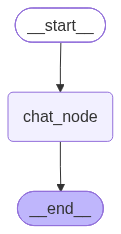

In [12]:
chatbot

In [13]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [16]:
thread_id='1'# 3 change
while True:
  user_message=input("type here : ")
  print("User: ",user_message)

  if user_message.strip().lower() in['exit','bye']:
    break
  config={'configurable':{'thread_id':thread_id}}   # 4 change
  response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)  # 5 change
  print('AI',response['messages'][-1].content)

type here : h
User:  h


AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [17]:
chatbot.get_state(config=config)# 6 change it will tell the all converstations in python object format

ValueError: No checkpointer set